# 9. Differentiable Fast & Furious

Fast & Furious¹² is a celebrated focal-plane wavefront sensing algorithm: from just a science image, a *tiny known DM move*, and a second image, it reconstructs the wavefront — no wavefront sensor, no defocus diversity, no extra hardware. The catch is the machinery: a weak-phase linearization, even/odd image algebra, regularized inversions and filtering, and with them hard limits — aberrations below ~1 radian and a symmetric, unaberrated-amplitude pupil.

Two ways past those limits have been shown: extending the algebra to specific symmetric coronagraphs, or replacing the estimator outright with a deep neural network trained on the instrument model — the sequential-diversity analog³ validated on the SCExAO optical bench with exactly these inputs. This tutorial takes a third path: **gradient descent through the telescope model itself**. The raw F&F inputs — frame, known nudge, frame — go into a generic least-squares loss, and `jit(vmap(grad))` does the rest. No linearization means no ~1 rad ceiling: we recover a wavefront of **1.8 rad rms** (Strehl ≈ 4%) to nanometer residuals in one shot, through photon noise, and close the loop at gain 1.

Why does F&F need two frames at all? A centrosymmetric pupil (circular, obstructed, symmetric spiders — most telescopes) has a *twin-image ambiguity*: the wavefront φ(x) and its parity twin −φ(−x) produce **pixel-identical** PSFs. In Zernike terms the twin negates every even-azimuthal-order mode (focus, astigmatism, spherical) and keeps the odd ones — so a single in-focus image cannot tell the two apart. The second frame, taken after a known DM move, breaks the tie: the twin predicts the wrong second image unless the move has zero even content. We will see all of this directly.

This notebook runs in **two acts**. Act 1 is the F&F-equivalent workflow on a plain telescope — without the original algorithm's caveats. Act 2 sends the *same recipe, unchanged*, through a **vector vortex coronagraph**, where the linear machinery cannot go at all — and ends on a twist the coronagraph's own symmetry provides.

Install the pieces with `pip install "telescope-sim[jax]" zodiax optax` (zodiax brings equinox; Python ≥ 3.11).

---
¹ C. U. Keller *et al.*, “Extremely fast focal-plane wavefront sensing for extreme adaptive optics,” Proc. SPIE 8447, 844721 (2012).

² V. Korkiakoski *et al.*, “Fast & Furious focal-plane wavefront sensing,” Appl. Opt. 53, 4565 (2014).

³ A deep-learning analog of F&F using the same two-frames-plus-move inputs, validated on the SCExAO optical bench: M. Bottom *et al.*, “Sequential coronagraphic low-order wavefront control,” AO4ELT7 proceedings (2023).

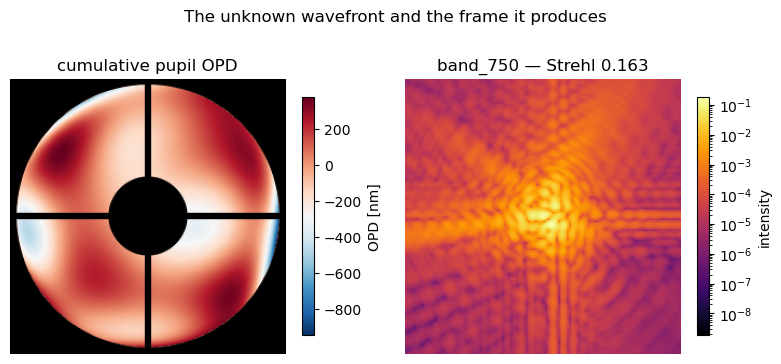

In [1]:
import hcipy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from telescope_sim.config.loader import build
from telescope_sim.config.schema import SimConfig
from telescope_sim.helpers.diagnostics import plot_opd_and_psfs

# A deliberately even (centrosymmetric) pupil: 8 m circular aperture,
# 30% central obstruction, 4 symmetric spiders — built by handing the
# stock HCIPy generator to the external_pupil aperture. The corrector
# is a 35-mode Zernike DM (Noll 2-36), observed through one 6% band
# at 750 nm.
config = {
    "backend": "jax",
    "pupil": {"resolution": 256, "extent": 8.4},
    "aperture": {
        "type": "external_pupil", "module": "hcipy",
        "function": "make_obstructed_circular_aperture",
        "mode": "callable", "supersample": 16,
        "kwargs": {"pupil_diameter": 8.0, "central_obscuration_ratio": 0.30,
                   "num_spiders": 4, "spider_width": 0.20},
        "area": 45.7,
    },
    "correctors": {
        "dm": {
            "type": "zernike", "n_modes": 35, "zernike_diameter": 8.0,
            "actuate_scale": 1.0e-6,
            "wavefront_role": "actuate",
            "target_strategy": "actuators", "target": True,
        }
    },
    "corrector_chain": ["dm"],
    "focal_planes": {
        "band_750": {
            "type": "angular", "central_lam": 0.75e-6,
            "focal_extent": 0.768, "focal_res": 128,
            "fractional_bandwidth": 0.06, "num_samples": 5,
        }
    },
    "outputs": {
        "psf": {"tap": {"type": "intensity", "focal_planes": ["band_750"]},
                "post_processing": [{"type": "max_intensity_norm"}]}
    },
    "strehl_method": "matched_filter",
    "strehl_core_rad": 5.6e-7,
}
sim = build(SimConfig.model_validate(config))

# The unknown state: 35 Zernike coefficients, about 1.8 rad rms of
# wavefront — far beyond the ~1 rad weak-phase limit of classical
# focal-plane sensing. Strehl is a few percent.
rng = np.random.default_rng(0)
coeffs_true = rng.normal(0.0, 0.06, 35)

out = sim.sample({"dm": coeffs_true}, meas_strehl=True, meas_pupil_opd=True)
plot_opd_and_psfs(sim, out,
                  suptitle="The unknown wavefront and the frame it produces")
plt.show()


## The twin: why one frame is not enough

Build the parity twin — negate the even-azimuthal-order coefficients, keep the odd — and render both. The two wavefronts are entirely different, yet their PSFs agree to machine precision: no amount of fitting a single frame can choose between them.

twin max image difference: 8.67e-18 (peak 1.08e-02)


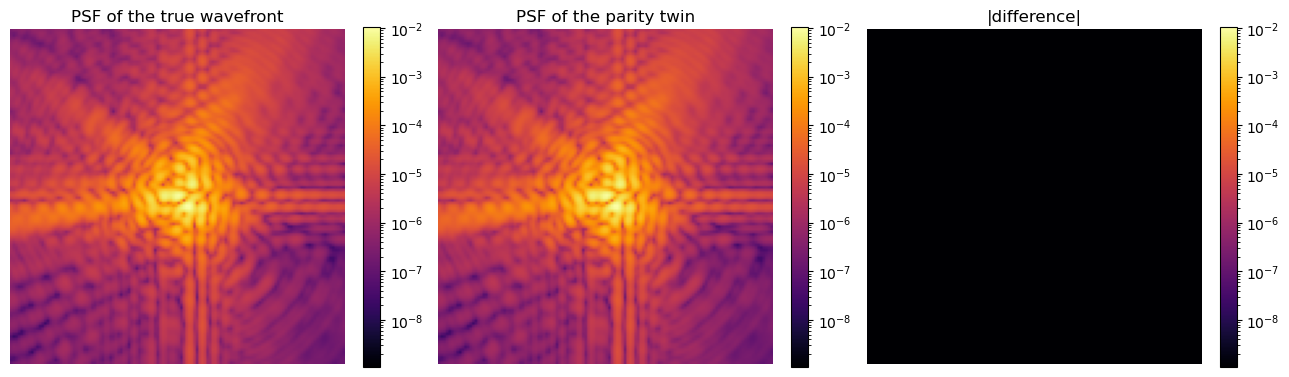

In [2]:
import jax
import jax.numpy as jnp

# Parity of Z_n^m under point reflection is (-1)^m: the twin
# -phi(-x) negates even-m modes and keeps odd-m modes.
m_orders = np.array([hcipy.noll_to_zernike(i + 2)[1] for i in range(35)])
twin_sign = np.where(np.abs(m_orders) % 2 == 1, 1.0, -1.0)
coeffs_twin = twin_sign * coeffs_true

forward = sim.forward_fn()


def frame(coeffs):
    img = forward({"dm": jnp.asarray(coeffs)})["band_750"]
    return img / img.sum()  # flux-normalized: photometry-free


img_true, img_twin = np.asarray(frame(coeffs_true)), np.asarray(frame(coeffs_twin))
print(f"twin max image difference: {np.abs(img_true - img_twin).max():.2e} "
      f"(peak {img_true.max():.2e})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
peak = img_true.max()
for ax, img, title in [
    (axes[0], img_true, "PSF of the true wavefront"),
    (axes[1], img_twin, "PSF of the parity twin"),
    (axes[2], np.abs(img_true - img_twin) + peak * 1e-16, "|difference|"),
]:
    im = ax.imshow(img, cmap="inferno", norm=LogNorm(vmin=peak * 1e-7, vmax=peak))
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()


## The measurement: frame, nudge, frame

The F&F acquisition, verbatim: take a frame, command a small *random* DM move (a fraction of a radian — the star stays on target), take a second frame. Both frames are detected at a 10⁶-photon budget — the shot-noise speckle is plainly visible in the wings. Wrapping `forward_fn` in a `zodiax.Base` module makes the coefficient vector a model parameter, dLux-style; the known move enters as an offset at evaluation time.

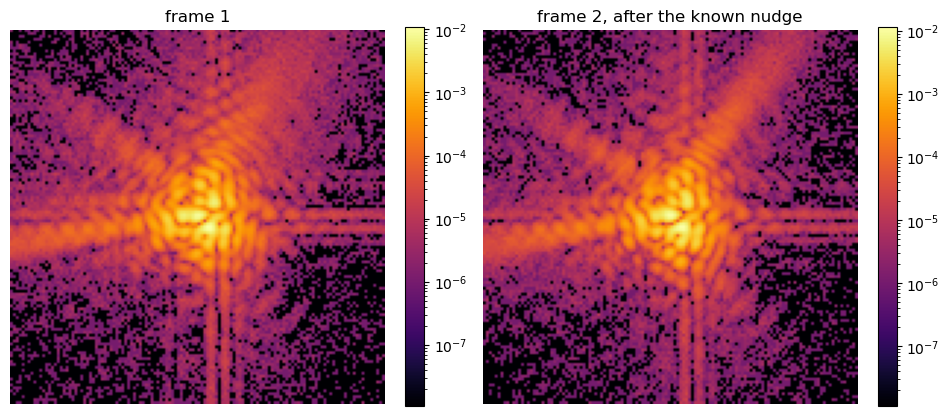

In [3]:
import equinox as eqx
import optax
import zodiax as zdx


class FFModel(zdx.Base):
    coeffs: jax.Array  # (35,) Zernike coefficients — the free parameters
    forward: object    # the telescope's pure forward model (static)

    def __init__(self, sim, coeffs=None):
        self.forward = sim.forward_fn()
        self.coeffs = jnp.zeros(35) if coeffs is None else jnp.asarray(coeffs, float)

    def model(self, offset=0.0):
        img = self.forward({"dm": self.coeffs + offset})["band_750"]
        return img / img.sum()


N_PHOTONS = 1e6
noise_key = jax.random.PRNGKey(7)


def measure(img, k):
    counts = jax.random.poisson(jax.random.fold_in(noise_key, k), img * N_PHOTONS)
    return counts / counts.sum()


truth = FFModel(sim, coeffs_true)   # plays the sky + telescope
model = FFModel(sim)                # what the fit gets to adjust

start_rng = np.random.default_rng(99)
move = jnp.asarray(start_rng.normal(0.0, 0.01, 35))  # the known nudge

frame_1 = measure(truth.model(), 0)
frame_2 = measure(truth.model(offset=move), 1)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
for ax, img, title in [
    (axes[0], np.asarray(frame_1), "frame 1"),
    (axes[1], np.asarray(frame_2), "frame 2, after the known nudge"),
]:
    peak = float(img.max())
    # clip zero-count pixels to the display floor - LogNorm would
    # otherwise render them as blank 'bad' pixels
    im = ax.imshow(np.maximum(img, peak * 1e-6), cmap="inferno",
                   norm=LogNorm(vmin=peak * 1e-6, vmax=peak))
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()


## The fit: multi-start descent, nothing else

The loss is plain least squares on amplitudes (square roots of intensities), summed over the two frames — the second evaluated with the known move applied. That is the *entire* algorithm.

The landscape is not convex, so we run many descents at once: batch the coefficient leaf to `(N, 35)`, `vmap` the per-start loss, and sum — gradients don't couple across starts and adam is elementwise, so one ordinary loop runs 32 independent descents in lockstep on-device. A few starts fall into the (now shallow) twin basin and simply lose the final argmin.

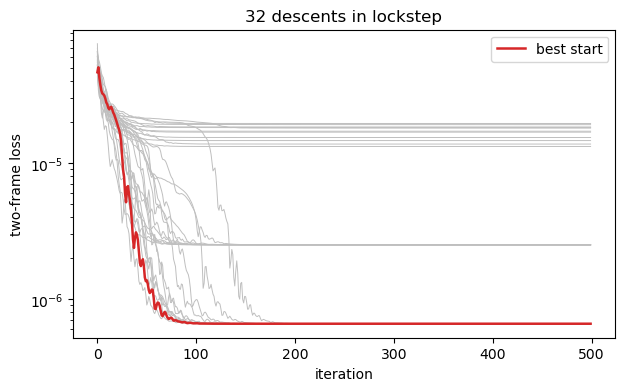

In [4]:
def one_loss(coeffs, model, f1, f2, move):
    m = model.set("coeffs", coeffs)
    return (jnp.mean((jnp.sqrt(m.model()) - jnp.sqrt(f1)) ** 2)
            + jnp.mean((jnp.sqrt(m.model(offset=move)) - jnp.sqrt(f2)) ** 2))


@eqx.filter_jit
@eqx.filter_value_and_grad(has_aux=True)
def loss_fn(params, model, f1, f2, move):
    per_start = jax.vmap(one_loss, in_axes=(0, None, None, None, None))(
        params["coeffs"], model, f1, f2, move)
    return per_start.sum(), per_start


N_STARTS, ITERS = 32, 500
starts = np.zeros((N_STARTS, 35))
starts[1:] = start_rng.normal(0.0, 0.06, (N_STARTS - 1, 35))

params = {"coeffs": jnp.asarray(starts)}
optim, state = zdx.map_optimisers(
    params, {"coeffs": optax.adam(optax.cosine_decay_schedule(3e-2, ITERS))})

history = []
for _ in range(ITERS):
    (_, per_start), grads = loss_fn(params, model, frame_1, frame_2, move)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    history.append(np.asarray(per_start))
history = np.array(history)

best = int(history[-1].argmin())
coeffs_rec = np.asarray(params["coeffs"][best], dtype=float)

plt.figure(figsize=(7, 4))
plt.semilogy(history, color="0.75", lw=0.7)
plt.semilogy(history[:, best], color="C3", lw=1.8, label="best start")
plt.xlabel("iteration")
plt.ylabel("two-frame loss")
plt.legend()
plt.title(f"{N_STARTS} descents in lockstep")
plt.show()


## The recovered wavefront

All 35 coefficients land on the diagonal — including the even-m modes a single frame is blind to (red). The residuals are a few nanometers of OPD, set by the photon noise.

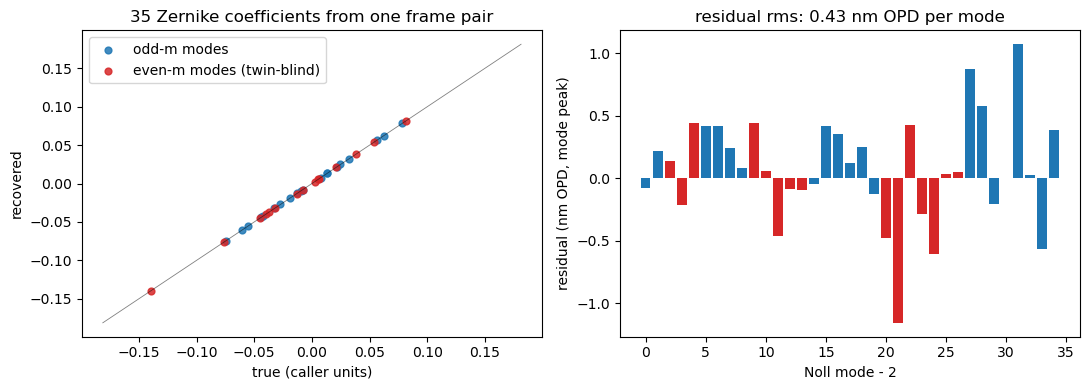

In [5]:
t, h = coeffs_true, coeffs_rec
res = h - t
even = twin_sign < 0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(t[~even], h[~even], s=24, color="C0",
                label="odd-m modes", alpha=0.85)
axes[0].scatter(t[even], h[even], s=24, color="C3",
                label="even-m modes (twin-blind)", alpha=0.85)
lim = np.abs(t).max() * 1.3
axes[0].plot([-lim, lim], [-lim, lim], "k-", lw=0.6, alpha=0.5)
axes[0].set_xlabel("true (caller units)")
axes[0].set_ylabel("recovered")
axes[0].set_title("35 Zernike coefficients from one frame pair")
axes[0].legend()

axes[1].bar(np.arange(35), res * 2e3,
            color=["C3" if e else "C0" for e in even])
axes[1].set_xlabel("Noll mode - 2")
axes[1].set_ylabel("residual (nm OPD, mode peak)")
axes[1].set_title(
    f"residual rms: {np.sqrt(np.mean(res ** 2)) * 2e3:.2f} nm OPD per mode")
fig.tight_layout()
plt.show()


## Closing the loop, F&F style

Because the estimate comes from the full nonlinear model, we can correct at **gain 1** — no leaky integrator nursing a linearization. And here is Fast & Furious' elegant trick, inherited whole: *the correction we just applied is itself the known move for the next frame pair*. Each new frame extends the loop for free; a short warm refit from the current estimate keeps up with 8 starts and 200 iterations.

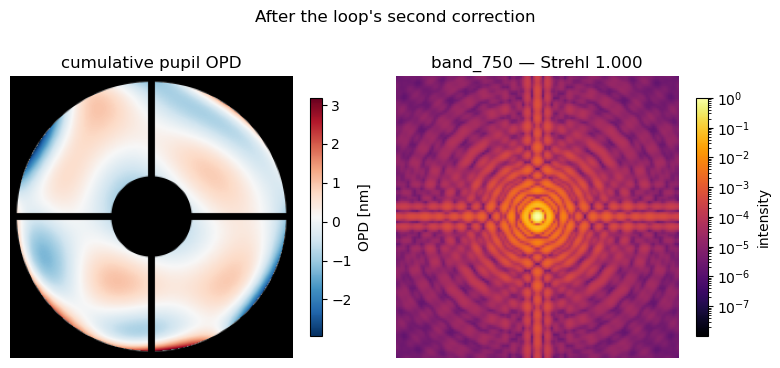

strehls: {'band_750': 1.0}


In [6]:
# Apply the correction (gain 1) and take the next frame. The DM
# state changes by (-coeffs_rec - move) relative to frame 2 - that
# difference is exactly known, and becomes the next pair's move.
correction = -coeffs_rec
frame_3 = measure(truth.model(offset=jnp.asarray(correction)), 2)
move_23 = jnp.asarray(correction) - move

# Fitting the (frame_2, frame_3) pair estimates the wavefront at
# frame 2's DM state (truth + move): warm-start there, and subtract
# the move afterwards to get back the estimate of the truth.
warm = np.repeat((coeffs_rec + np.asarray(move))[None], 8, axis=0)
warm[1:] += start_rng.normal(0.0, 0.02, (7, 35))
params = {"coeffs": jnp.asarray(warm)}
optim, state = zdx.map_optimisers(
    params, {"coeffs": optax.adam(optax.cosine_decay_schedule(1e-2, 200))})
for _ in range(200):
    (_, per_start), grads = loss_fn(
        params, model, frame_2, frame_3, move_23)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
coeffs_rec2 = np.asarray(params["coeffs"][int(np.asarray(per_start).argmin())])
coeffs_rec2 = coeffs_rec2 - np.asarray(move)

corrected = sim.sample({"dm": coeffs_true - coeffs_rec2}, meas_strehl=True,
                       meas_pupil_opd=True)
plot_opd_and_psfs(sim, corrected,
                  suptitle="After the loop's second correction")
plt.show()
print("strehls:", {k: round(float(v), 4)
                   for k, v in corrected['strehls'].items()})


## Act 2: through the vector vortex coronagraph

Focal-plane sensing *through a coronagraph* is where the linear F&F machinery stops entirely: the vortex's complex focal-plane mask breaks the even/odd image algebra it is built on — this is the regime the deep-learning analog³ was invented for. For gradient descent nothing changes: the coronagraph is just more differentiable model, and the recipe below is *identical* to act 1's.

The twin ambiguity survives the coronagraph in a surprising way. A charge +2 vortex maps the parity twin's image onto the truth's image *through charge −2* — a charge swap — and an unpolarized vector vortex averages the two charges, so the average is blind to the swap: behind the VVC the twin is exactly as invisible as behind no coronagraph at all. One frame cannot choose; the F&F pair still can. (Hold on to that charge-swap fact — it pays off at the end.)

A coronagraph operates behind an adaptive-optics system, so act 2's unknown wavefront is a post-AO residual of ~0.9 rad rms. The vortex propagation train is heavier than a plain focal plane, so this act runs on a 128-pixel pupil grid to keep the notebook quick.

twin max image difference through the VVC: 1.64e-08 (peak 6.00e-03)


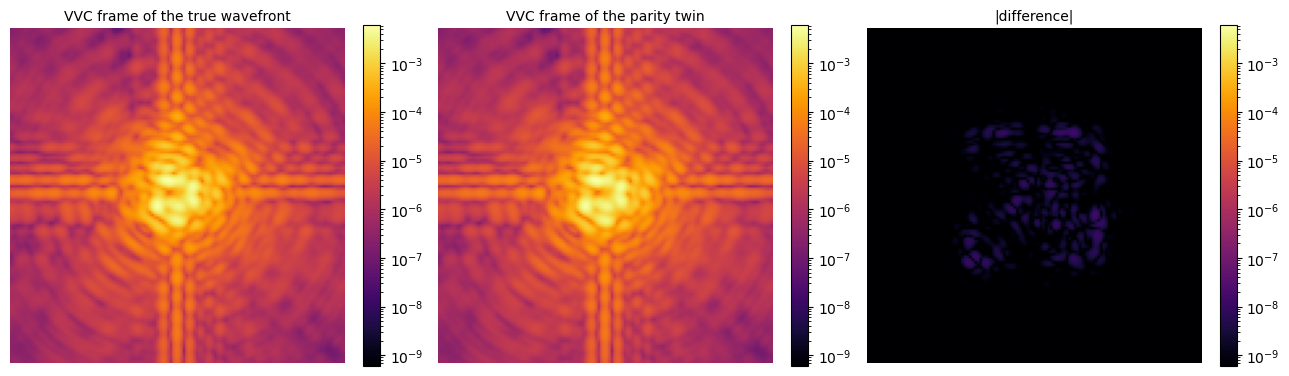

In [7]:
import copy

config_vvc = copy.deepcopy(config)
config_vvc["pupil"]["resolution"] = 128
config_vvc["coronagraph"] = {
    "type": "vector_vortex", "charge": 2,
    "lyot": {"type": "external_pupil", "module": "hcipy",
             "function": "make_circular_aperture", "mode": "callable",
             "kwargs": {"diameter": 7.2}, "supersample": 16},
}
sim_vvc = build(SimConfig.model_validate(config_vvc))

coeffs_vvc_true = rng.normal(0.0, 0.03, 35)  # ~0.9 rad rms post-AO residual

truth_vvc = FFModel(sim_vvc, coeffs_vvc_true)
twin_vvc = FFModel(sim_vvc, twin_sign * coeffs_vvc_true)
img_t, img_w = np.asarray(truth_vvc.model()), np.asarray(twin_vvc.model())
print(f"twin max image difference through the VVC: "
      f"{np.abs(img_t - img_w).max():.2e} (peak {img_t.max():.2e})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
peak = img_t.max()
for ax, img, title in [
    (axes[0], img_t, "VVC frame of the true wavefront"),
    (axes[1], img_w, "VVC frame of the parity twin"),
    (axes[2], np.abs(img_t - img_w) + peak * 1e-16, "|difference|"),
]:
    im = ax.imshow(img, cmap="inferno", norm=LogNorm(vmin=peak * 1e-7, vmax=peak))
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()


## The same fit, behind the coronagraph

Frame, nudge, frame — through the vortex this time, at the same 10⁶-photon budget — and the identical multi-start descent. The only new line of physics is in the configuration.

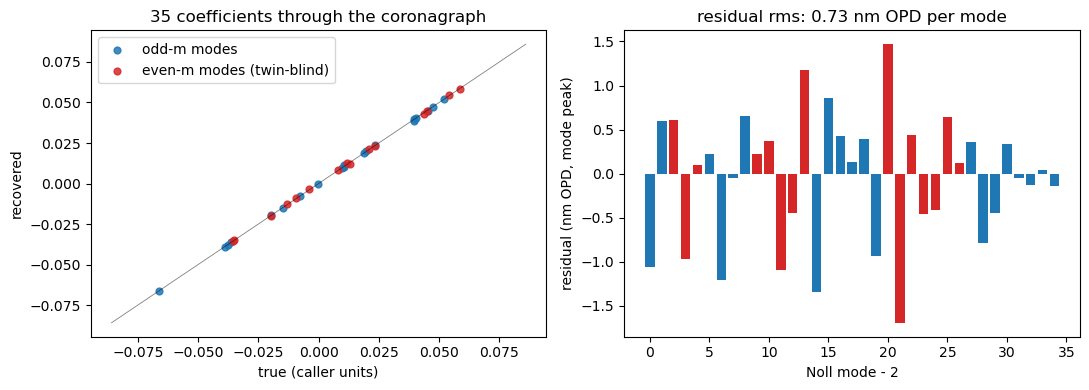

In [8]:
model_vvc = FFModel(sim_vvc)
move_vvc = jnp.asarray(start_rng.normal(0.0, 0.01, 35))
frame_v1 = measure(truth_vvc.model(), 3)
frame_v2 = measure(truth_vvc.model(offset=move_vvc), 4)

N_STARTS2, ITERS2 = 16, 350
starts2 = np.zeros((N_STARTS2, 35))
starts2[1:] = start_rng.normal(0.0, 0.03, (N_STARTS2 - 1, 35))

params = {"coeffs": jnp.asarray(starts2)}
optim, state = zdx.map_optimisers(
    params, {"coeffs": optax.adam(optax.cosine_decay_schedule(3e-2, ITERS2))})
for _ in range(ITERS2):
    (_, per_start), grads = loss_fn(params, model_vvc, frame_v1, frame_v2,
                                    move_vvc)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
vvc_rec = np.asarray(params["coeffs"][int(np.asarray(per_start).argmin())],
                     dtype=float)

t2, h2 = coeffs_vvc_true, vvc_rec
res2 = h2 - t2
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(t2[~even], h2[~even], s=24, color="C0",
                label="odd-m modes", alpha=0.85)
axes[0].scatter(t2[even], h2[even], s=24, color="C3",
                label="even-m modes (twin-blind)", alpha=0.85)
lim = np.abs(t2).max() * 1.3
axes[0].plot([-lim, lim], [-lim, lim], "k-", lw=0.6, alpha=0.5)
axes[0].set_xlabel("true (caller units)")
axes[0].set_ylabel("recovered")
axes[0].set_title("35 coefficients through the coronagraph")
axes[0].legend()
axes[1].bar(np.arange(35), res2 * 2e3,
            color=["C3" if e else "C0" for e in even])
axes[1].set_xlabel("Noll mode - 2")
axes[1].set_ylabel("residual (nm OPD, mode peak)")
axes[1].set_title(
    f"residual rms: {np.sqrt(np.mean(res2 ** 2)) * 2e3:.2f} nm OPD per mode")
fig.tight_layout()
plt.show()


## Restoring the null

Apply the recovered correction and the coronagraph does its job again: the leaked starlight collapses back into the null. The Strehl, measured through the plain telescope, confirms the wavefront itself is fixed.

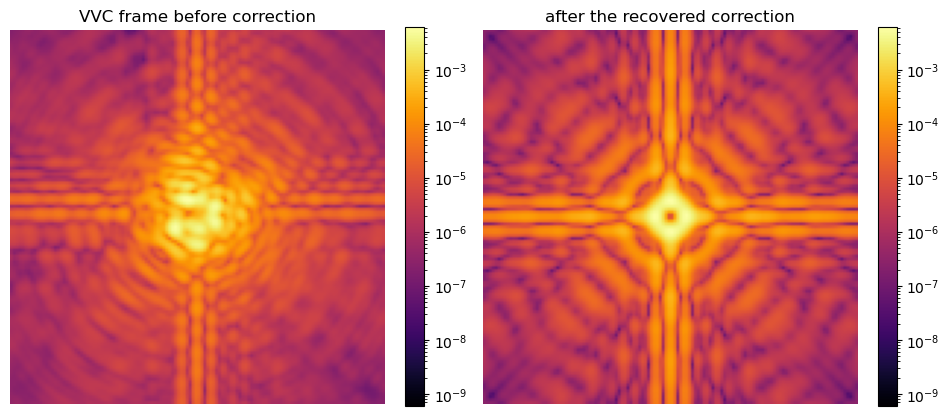

strehls after correction: {'band_750': 0.9999}


In [9]:
img_before = np.asarray(truth_vvc.model())
img_after = np.asarray(FFModel(sim_vvc, coeffs_vvc_true - vvc_rec).model())

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
peak = img_before.max()
for ax, img, title in [
    (axes[0], img_before, "VVC frame before correction"),
    (axes[1], img_after, "after the recovered correction"),
]:
    im = ax.imshow(img, cmap="inferno", norm=LogNorm(vmin=peak * 1e-7, vmax=peak))
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

corrected_vvc = sim.sample({"dm": coeffs_vvc_true - vvc_rec}, meas_strehl=True)
print("strehls after correction:",
      {k: round(float(v), 4) for k, v in corrected_vvc['strehls'].items()})


## The polarization twist: one frame, no nudge

Now cash in the charge-swap fact. A *vector* vortex acts on the two circular polarizations with opposite charges — the unpolarized image averages them, which is what restored the twin degeneracy. But image a **single polarization channel** and only one charge remains: the twin now produces the *opposite-charge* image, which is visibly different. The ambiguity that has driven this entire notebook — the reason Fast & Furious needs two frames — simply never arises.

So through one polarization channel, a **single frame with no diversity move at all** determines the full wavefront:

In [10]:
config_pol = copy.deepcopy(config_vvc)
config_pol["coronagraph"]["type"] = "vortex"  # one charge = one circular polarization
sim_pol = build(SimConfig.model_validate(config_pol))

truth_pol = FFModel(sim_pol, coeffs_vvc_true)   # same unknown wavefront
twin_diff = float(np.abs(np.asarray(truth_pol.model())
                         - np.asarray(FFModel(sim_pol, twin_sign * coeffs_vvc_true).model())).max())
print(f"twin max image difference in one polarization channel: {twin_diff:.2e} "
      f"- the twin the unpolarized VVC hid is exposed at full amplitude")

frame_p = measure(truth_pol.model(), 5)  # ONE frame, no nudge


def one_loss_single(coeffs, model, f1):
    m = model.set("coeffs", coeffs).model()
    return jnp.mean((jnp.sqrt(m) - jnp.sqrt(f1)) ** 2)


@eqx.filter_jit
@eqx.filter_value_and_grad(has_aux=True)
def single_loss_fn(params, model, f1):
    per_start = jax.vmap(one_loss_single, in_axes=(0, None, None))(
        params["coeffs"], model, f1)
    return per_start.sum(), per_start


model_pol = FFModel(sim_pol)
params = {"coeffs": jnp.asarray(starts2)}
optim, state = zdx.map_optimisers(
    params, {"coeffs": optax.adam(optax.cosine_decay_schedule(3e-2, 300))})
for _ in range(300):
    (_, per_start), grads = single_loss_fn(params, model_pol, frame_p)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
pol_rec = np.asarray(params["coeffs"][int(np.asarray(per_start).argmin())],
                     dtype=float)

res_p = pol_rec - coeffs_vvc_true
corrected_pol = sim.sample({"dm": coeffs_vvc_true - pol_rec}, meas_strehl=True)
print(f"single-frame residual rms: {np.sqrt(np.mean(res_p ** 2)) * 2e3:.2f} nm OPD per mode")
print("strehls after correction:",
      {k: round(float(v), 4) for k, v in corrected_pol['strehls'].items()})


twin max image difference in one polarization channel: 6.17e-03 - the twin the unpolarized VVC hid is exposed at full amplitude


single-frame residual rms: 0.71 nm OPD per mode
strehls after correction: {'band_750': 0.9999}


## Notes

- The classical algorithm's restrictions came from its linearization, not from the measurement: with the model differentiable end-to-end, the same two frames handle 1.8 rad of aberration, any pupil, a vector vortex coronagraph, and photon noise — and the recipe contains no step specific to any of them. The coronagraph entered this notebook purely as configuration.
- These are demonstrations against the instrument model itself (with photon shot noise); the validation campaigns behind the pinned numbers reproduce every conclusion — the pair's necessity behind the VVC, its nanometer-level accuracy, and the single-channel result — against independently discretized data.
- Swap the corrector or the aperture freely: `forward_fn` probes correctors numerically, so a segmented mirror or an `actuator_grid` DM exports identically.
- The model is an ordinary pytree — hand the same loss to a JAX-native sampler (numpyro, blackjax) for posteriors, or fit instrument parameters alongside the wavefront.